# 04 — Qwen3-8B QLoRA Fine-Tuning for Legal Summarization

This notebook fine-tunes Qwen/Qwen3-8B on the chunk-summary SFT records created by notebook 03. It uses 4-bit NF4 QLoRA, assistant-only loss masking, validation-based checkpoint selection, early stopping, experiment logging, adapter-only saving, and a post-training sanity check.

The notebook reads preprocessing_report.json at runtime, so the training sequence length always matches the selected preprocessing profile. It does not use the model's full 32K context unless notebook 03 actually produced examples at that length.

## 1. Environment setup

Recommended environment: Python 3.10–3.12, CUDA-capable PyTorch, and `transformers==5.6.2` to match notebook 03 exactly. Run the commented installation command once if the environment is missing packages, then restart the kernel.

In [2]:
%pip install --upgrade --no-cache-dir "bitsandbytes>=0.46.1"

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Uncomment and run once when needed.
%pip install -U "transformers==5.6.2" "peft>=0.15" "accelerate>=1.5" \
    "bitsandbytes>=0.45" "datasets>=3.2" tensorboard matplotlib pandas python-dotenv packaging

Note: you may need to restart the kernel to use updated packages.


## 2. Configuration

In [4]:
from pathlib import Path
import json
import math
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
PROJECT_ROOT = Path(os.getenv(
    "LEGALMIND_PROJECT_ROOT",
    "/data2/user_data/sg57092c/LLM_finetune",
)).expanduser()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "qwen3_8b_long_document"
PREPROCESSING_REPORT = (
    PROJECT_ROOT / "artifacts" / "qwen3_8b_long_document_preprocessing" / "preprocessing_report.json"
)
RUN_ROOT = PROJECT_ROOT / "models" / "qwen3_8b_legal_qlora"
CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
ADAPTER_DIR = RUN_ROOT / "adapter"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "qwen3_8b_qlora_training"

MODEL_NAME = "Qwen/Qwen3-8B"
RANDOM_SEED = 42

# Whole-data training is the default. Set LEGAL_SMOKE_TEST=1 for a short pipeline test.
SMOKE_TEST = os.getenv("LEGAL_SMOKE_TEST", "0") == "1"
RUN_TRAINING = os.getenv("LEGAL_RUN_TRAINING", "1") == "1"
SMOKE_TRAIN_ROWS = 64
SMOKE_VALIDATION_ROWS = 16
SMOKE_MAX_STEPS = 25
CHECKPOINT_VALIDATION_ROWS = 500

NUM_TRAIN_EPOCHS = 2
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 0.3

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

EVAL_STEPS = 5 if SMOKE_TEST else 250
SAVE_STEPS = EVAL_STEPS
LOGGING_STEPS = 1 if SMOKE_TEST else 10
EARLY_STOPPING_PATIENCE = 3
ATTN_IMPLEMENTATION = os.getenv("LEGAL_ATTN_IMPLEMENTATION", "sdpa")
REPORT_TO = os.getenv("LEGAL_REPORT_TO", "tensorboard").strip().lower()
RESUME_FROM_CHECKPOINT = os.getenv("LEGAL_RESUME_CHECKPOINT", "").strip() or None
MAP_NUM_PROC = int(os.getenv("LEGAL_MAP_NUM_PROC", "1"))

for directory in (CHECKPOINT_DIR, ADAPTER_DIR, ARTIFACT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Run mode     :", "SMOKE TEST" if SMOKE_TEST else "FULL DATASET")
print("Attention    :", ATTN_IMPLEMENTATION)

Project root : /data2/user_data/sg57092c/LLM_finetune
Processed data: /data2/user_data/sg57092c/LLM_finetune/data/processed/qwen3_8b_long_document
Run mode     : FULL DATASET
Attention    : sdpa


## 3. Imports, versions, GPU and reproducibility

In [5]:
import platform
from importlib.metadata import PackageNotFoundError, version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from datasets import load_dataset
from packaging.version import Version
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
)
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

EXPECTED_TRANSFORMERS_VERSION = "5.6.2"
if transformers.__version__ != EXPECTED_TRANSFORMERS_VERSION:
    raise RuntimeError(
        f"Use transformers=={EXPECTED_TRANSFORMERS_VERSION} to match notebook 03; "
        f"found {transformers.__version__}."
    )
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is required for bitsandbytes QLoRA training.")

set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.backends.cuda.matmul.allow_tf32 = torch.cuda.get_device_capability(0)[0] >= 8

def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"

gpu = torch.cuda.get_device_properties(0)
gpu_memory_gib = gpu.total_memory / 1024**3
USE_BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16

environment = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "peft": package_version("peft"),
    "accelerate": package_version("accelerate"),
    "bitsandbytes": package_version("bitsandbytes"),
    "datasets": package_version("datasets"),
    "gpu": gpu.name,
    "gpu_memory_gib": round(gpu_memory_gib, 2),
    "compute_dtype": str(COMPUTE_DTYPE),
}
display(pd.DataFrame([environment]))
print("BF16 enabled:", USE_BF16)

,python,torch,transformers,peft,accelerate,bitsandbytes,datasets,gpu,gpu_memory_gib,compute_dtype
0,3.12.3,2.5.1+cu121,5.6.2,0.20.0,1.14.0,0.50.2,5.0.1,NVIDIA H100 80GB HBM3,79.19,torch.bfloat16


BF16 enabled: True


## 4. Load preprocessing lineage and artifacts

This is the connection to notebook 03. Training stops if its quality gates failed, its tokenizer differs from the selected model, or required JSONL files are missing.

In [6]:
required_paths = {
    "report": PREPROCESSING_REPORT,
    "train": PROCESSED_DIR / "sft_train.jsonl",
    "validation": PROCESSED_DIR / "sft_validation.jsonl",
}
missing = [str(path) for path in required_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing notebook 03 artifacts:\n- " + "\n- ".join(missing)
        + "\nRun 03_long_document_preprocessing.ipynb successfully first."
    )

with open(PREPROCESSING_REPORT, encoding="utf-8") as file:
    preprocessing_report = json.load(file)

if preprocessing_report["tokenizer"] != MODEL_NAME:
    raise ValueError(
        f"Tokenizer mismatch: preprocessing used {preprocessing_report['tokenizer']}, "
        f"but training requested {MODEL_NAME}."
    )

failed_gates = [
    name for name, passed in preprocessing_report.get("quality_gates", {}).items()
    if not passed
]
if failed_gates:
    raise ValueError(f"Notebook 03 quality gates failed: {failed_gates}")

MAX_SEQUENCE_TOKENS = int(preprocessing_report["train_sequence_tokens"])
TRAINING_PROFILE = preprocessing_report.get("training_profile", "unknown")

if MAX_SEQUENCE_TOKENS >= 8192 and gpu_memory_gib < 35:
    print(
        "WARNING: 8K QLoRA sequences may exceed this GPU's memory. "
        "Use the 24gb preprocessing profile or reduce the sequence length."
    )

lineage_view = {
    "tokenizer": preprocessing_report["tokenizer"],
    "training_profile": TRAINING_PROFILE,
    "max_sequence_tokens": MAX_SEQUENCE_TOKENS,
    "train_sft_examples": preprocessing_report["train_sft_examples"],
    "validation_sft_examples": preprocessing_report["validation_sft_examples"],
    "skipped_pairs": preprocessing_report.get("skipped_pairs", 0),
    "skipped_pair_rate": preprocessing_report.get("skipped_pair_rate", 0.0),
    "semantic_match_rate": preprocessing_report.get("semantic_match_rate"),
    "unmatched_summary_sentences": preprocessing_report.get(
        "unmatched_summary_sentences", 0
    ),
    "rejected_chunk_targets": preprocessing_report.get("rejected_chunk_targets", 0),
    "target_rejection_rate": preprocessing_report.get("target_rejection_rate"),
    "truncated_targets": preprocessing_report.get("truncated_target_examples", 0),
    "target_truncation_rate": preprocessing_report.get("target_truncation_rate"),
}
if preprocessing_report.get("semantic_match_rate", 0.0) < 0.70:
    raise ValueError("Semantic alignment rate is below the 70% training threshold.")
if preprocessing_report.get("target_rejection_rate", 1.0) > 0.05:
    raise ValueError("More than 5% of aligned chunk targets were rejected.")
if preprocessing_report.get("target_truncation_rate", 1.0) > 0.10:
    raise ValueError("More than 10% of training targets were truncated.")
display(pd.DataFrame([lineage_view]))

,tokenizer,training_profile,max_sequence_tokens,train_sft_examples,validation_sft_examples,skipped_pairs,skipped_pair_rate,semantic_match_rate,unmatched_summary_sentences,rejected_chunk_targets,target_rejection_rate,truncated_targets,target_truncation_rate
0,Qwen/Qwen3-8B,24gb,4096,15333,1730,2,0.000286,0.959853,8363,222,0.012844,938,0.054973


## 5. Load and validate SFT datasets

In [7]:
data_files = {
    "train": str(required_paths["train"]),
    "validation": str(required_paths["validation"]),
}
raw_datasets = load_dataset("json", data_files=data_files)

if SMOKE_TEST:
    raw_datasets["train"] = raw_datasets["train"].select(
        range(min(SMOKE_TRAIN_ROWS, len(raw_datasets["train"])))
    )
    raw_datasets["validation"] = raw_datasets["validation"].select(
        range(min(SMOKE_VALIDATION_ROWS, len(raw_datasets["validation"])))
    )

# Use a deterministic subset for frequent loss evaluation and early stopping.
# The complete validation split is evaluated once after the best checkpoint is restored.
if SMOKE_TEST:
    raw_datasets["checkpoint_validation"] = raw_datasets["validation"]
else:
    raw_datasets["checkpoint_validation"] = (
        raw_datasets["validation"]
        .shuffle(seed=RANDOM_SEED)
        .select(range(min(CHECKPOINT_VALIDATION_ROWS, len(raw_datasets["validation"]))))
    )

required_columns = {
    "pair_id", "judgment_hash", "prompt", "text", "target_summary",
    "prompt_tokens", "target_tokens", "total_tokens",
}
for split_name, dataset in raw_datasets.items():
    missing_columns = required_columns - set(dataset.column_names)
    if missing_columns:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing_columns)}")

train_hashes = set(raw_datasets["train"]["judgment_hash"])
validation_hashes = set(raw_datasets["validation"]["judgment_hash"])
overlap = train_hashes & validation_hashes
if overlap:
    raise ValueError(f"Train/validation leakage detected: {len(overlap)} shared judgments")

minimum_target_tokens = int(preprocessing_report.get("minimum_target_tokens", 20))
dataset_summary = []
for split_name, dataset in raw_datasets.items():
    lengths = np.asarray(dataset["total_tokens"], dtype=np.int64)
    targets = np.asarray(dataset["target_tokens"], dtype=np.int64)
    dataset_summary.append({
        "split": split_name,
        "examples": len(dataset),
        "unique_cases": len(set(dataset["judgment_hash"])),
        "mean_total_tokens": round(float(lengths.mean()), 2),
        "p95_total_tokens": round(float(np.quantile(lengths, 0.95)), 2),
        "max_total_tokens": int(lengths.max()),
        "mean_target_tokens": round(float(targets.mean()), 2),
    })
    if lengths.max() > MAX_SEQUENCE_TOKENS:
        raise ValueError(
            f"{split_name} contains {lengths.max()} tokens, above "
            f"MAX_SEQUENCE_TOKENS={MAX_SEQUENCE_TOKENS}"
        )
    if targets.min() < minimum_target_tokens:
        raise ValueError(
            f"{split_name} contains a {targets.min()}-token target; "
            f"minimum is {minimum_target_tokens}."
        )

display(pd.DataFrame(dataset_summary))
print("PASS: schemas, target quality, sequence budgets and split isolation are valid.")

,split,examples,unique_cases,mean_total_tokens,p95_total_tokens,max_total_tokens,mean_target_tokens
0,train,15333,6301,2802.70,3791.00,3870,429.32
1,validation,1730,700,2791.47,3792.55,3867,424.76
2,checkpoint_validation,500,361,2811.60,3792.10,3867,429.10


PASS: schemas, target quality, sequence budgets and split isolation are valid.


## 6. Load tokenizer and build assistant-only labels

Notebook 03 stored both the Qwen-formatted prompt and complete conversation. Tokens belonging to the system and user prompt receive label -100, so cross-entropy loss is calculated only on the assistant's legal summary.

In [8]:
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / ".env")
hf_token = os.getenv("HF_TOKEN")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    token=hf_token or None,
    use_fast=True,
)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize_and_mask(record):
    if not record["text"].startswith(record["prompt"]):
        raise ValueError(f"Prompt is not a prefix for {record['pair_id']}")

    full_ids = tokenizer(
        record["text"],
        add_special_tokens=False,
        truncation=False,
    )["input_ids"]
    prompt_ids = tokenizer(
        record["prompt"],
        add_special_tokens=False,
        truncation=False,
    )["input_ids"]

    if full_ids[:len(prompt_ids)] != prompt_ids:
        raise ValueError(f"Prompt token prefix mismatch for {record['pair_id']}")
    if len(full_ids) > MAX_SEQUENCE_TOKENS:
        raise ValueError(
            f"{record['pair_id']} has {len(full_ids)} tokens; "
            f"limit is {MAX_SEQUENCE_TOKENS}"
        )

    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]
    supervised_tokens = sum(label != -100 for label in labels)
    if supervised_tokens == 0:
        raise ValueError(f"No assistant tokens remain for {record['pair_id']}")

    return {
        "input_ids": full_ids,
        "attention_mask": [1] * len(full_ids),
        "labels": labels,
    }

tokenized_datasets = raw_datasets.map(
    tokenize_and_mask,
    remove_columns=raw_datasets["train"].column_names,
    num_proc=MAP_NUM_PROC,
    desc="Tokenizing and masking prompts",
)

for split_name, dataset in tokenized_datasets.items():
    sample_count = min(200, len(dataset))
    supervised_counts = [
        sum(label != -100 for label in dataset[index]["labels"])
        for index in range(sample_count)
    ]
    assert min(supervised_counts) > 0
    print(
        f"{split_name}: checked {sample_count} examples; "
        f"assistant tokens min={min(supervised_counts)}, "
        f"mean={np.mean(supervised_counts):.1f}, max={max(supervised_counts)}"
    )

train: checked 200 examples; assistant tokens min=23, mean=273.6, max=1000
validation: checked 200 examples; assistant tokens min=25, mean=251.6, max=808
checkpoint_validation: checked 200 examples; assistant tokens min=23, mean=418.8, max=1001


## 7. Dynamic-padding causal-LM collator

In [9]:
from dataclasses import dataclass

@dataclass
class AssistantOnlyCollator:
    pad_token_id: int
    pad_to_multiple_of: int = 8

    def __call__(self, features):
        longest = max(len(feature["input_ids"]) for feature in features)
        padded_length = int(
            math.ceil(longest / self.pad_to_multiple_of) * self.pad_to_multiple_of
        )
        if padded_length > MAX_SEQUENCE_TOKENS:
            padded_length = MAX_SEQUENCE_TOKENS

        input_ids, attention_masks, labels = [], [], []
        for feature in features:
            length = len(feature["input_ids"])
            padding = padded_length - length
            if padding < 0:
                raise ValueError("A feature exceeds the configured sequence length")
            input_ids.append(feature["input_ids"] + [self.pad_token_id] * padding)
            attention_masks.append(feature["attention_mask"] + [0] * padding)
            labels.append(feature["labels"] + [-100] * padding)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_masks, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }

data_collator = AssistantOnlyCollator(tokenizer.pad_token_id)
test_batch = data_collator([
    tokenized_datasets["train"][0],
    tokenized_datasets["train"][min(1, len(tokenized_datasets["train"]) - 1)],
])
print({name: tuple(value.shape) for name, value in test_batch.items()})
assert (test_batch["labels"] == -100).any()
assert (test_batch["labels"] != -100).any()
print("PASS: assistant-only dynamic-padding batch created.")

{'input_ids': (2, 3064), 'attention_mask': (2, 3064), 'labels': (2, 3064)}
PASS: assistant-only dynamic-padding batch created.


## 8. Load Qwen3-8B in 4-bit NF4

In [10]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=hf_token or None,
    quantization_config=quantization_config,
    device_map={"": torch.cuda.current_device()},
    dtype=COMPUTE_DTYPE,
    attn_implementation=ATTN_IMPLEMENTATION,
    low_cpu_mem_usage=True,
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
)
model.gradient_checkpointing_enable(
    gradient_checkpointing_kwargs={"use_reentrant": False}
)
print("Loaded 4-bit base model on:", model.device)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Loaded 4-bit base model on: cuda:0


## 9. Attach LoRA adapters and verify trainable parameters

In [11]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=LORA_TARGET_MODULES,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_percentage = 100 * trainable_parameters / total_parameters

assert 0 < trainable_percentage < 2.0
print(f"Trainable: {trainable_parameters:,}")
print(f"Total represented parameters: {total_parameters:,}")
print(f"Trainable percentage: {trainable_percentage:.4f}%")
print("PASS: only parameter-efficient adapter weights are trainable.")

trainable params: 43,646,976 || all params: 8,234,382,336 || trainable%: 0.5301
Trainable: 43,646,976
Total represented parameters: 4,761,498,624
Trainable percentage: 0.9167%
PASS: only parameter-efficient adapter weights are trainable.


## 10. Training plan

In [12]:
world_size = int(os.getenv("WORLD_SIZE", "1"))
effective_batch_size = (
    PER_DEVICE_TRAIN_BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
    * world_size
)
updates_per_epoch = math.ceil(
    len(tokenized_datasets["train"]) / effective_batch_size
)
planned_updates = (
    SMOKE_MAX_STEPS
    if SMOKE_TEST
    else math.ceil(updates_per_epoch * NUM_TRAIN_EPOCHS)
)

training_plan = {
    "training_profile": TRAINING_PROFILE,
    "sequence_tokens": MAX_SEQUENCE_TOKENS,
    "train_examples": len(tokenized_datasets["train"]),
    "validation_examples": len(tokenized_datasets["validation"]),
    "checkpoint_validation_examples": len(
        tokenized_datasets["checkpoint_validation"]
    ),
    "per_device_batch": PER_DEVICE_TRAIN_BATCH_SIZE,
    "gradient_accumulation": GRADIENT_ACCUMULATION_STEPS,
    "world_size": world_size,
    "effective_batch": effective_batch_size,
    "epochs": NUM_TRAIN_EPOCHS,
    "planned_optimizer_updates": planned_updates,
    "learning_rate": LEARNING_RATE,
    "compute_dtype": str(COMPUTE_DTYPE),
}
display(pd.DataFrame([training_plan]))

,training_profile,sequence_tokens,train_examples,validation_examples,checkpoint_validation_examples,per_device_batch,gradient_accumulation,world_size,effective_batch,epochs,planned_optimizer_updates,learning_rate,compute_dtype
0,24gb,4096,15333,1730,500,1,8,1,8,2,3834,0.0002,torch.bfloat16


## 11. Configure Trainer

Checkpoints and validation are evaluated at the same interval so the best adapter can be restored. Early stopping monitors validation loss.

In [13]:
report_targets = [] if REPORT_TO in {"", "none"} else [REPORT_TO]

training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    run_name="qwen3-8b-legal-qlora",
    num_train_epochs=NUM_TRAIN_EPOCHS,
    max_steps=SMOKE_MAX_STEPS if SMOKE_TEST else -1,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    optim="paged_adamw_8bit",
    bf16=USE_BF16,
    fp16=not USE_BF16,
    tf32=torch.backends.cuda.matmul.allow_tf32,
    logging_strategy="steps",
    logging_steps=LOGGING_STEPS,
    logging_first_step=True,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=report_targets,
    seed=RANDOM_SEED,
    data_seed=RANDOM_SEED,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["checkpoint_validation"],
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )
    ],
)

print("Trainer ready.")
print("Resume checkpoint:", RESUME_FROM_CHECKPOINT or "none")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready.
Resume checkpoint: none


## 12. Train and evaluate

This is the cell where QLoRA training actually happens. Notebook 03 only prepared the training examples.

In [14]:
if RUN_TRAINING:
    train_result = trainer.train(
        resume_from_checkpoint=RESUME_FROM_CHECKPOINT
    )
    # Training restores the best checkpoint selected on the fixed validation subset.
    checkpoint_evaluation_metrics = trainer.evaluate(
        eval_dataset=tokenized_datasets["checkpoint_validation"],
        metric_key_prefix="checkpoint_validation",
    )
    evaluation_metrics = trainer.evaluate(
        eval_dataset=tokenized_datasets["validation"],
        metric_key_prefix="full_validation",
    )

    trainer.log_metrics("train", train_result.metrics)
    trainer.log_metrics("checkpoint_validation", checkpoint_evaluation_metrics)
    trainer.log_metrics("full_validation", evaluation_metrics)

    if "full_validation_loss" in evaluation_metrics:
        evaluation_metrics["full_validation_perplexity"] = float(
            math.exp(min(20, evaluation_metrics["full_validation_loss"]))
        )

    model.save_pretrained(ADAPTER_DIR, safe_serialization=True)
    tokenizer.save_pretrained(ADAPTER_DIR)
    trainer.save_state()
    print("Adapter saved to:", ADAPTER_DIR)
else:
    train_result = None
    checkpoint_evaluation_metrics = {}
    evaluation_metrics = {}
    print("Training skipped because LEGAL_RUN_TRAINING=0.")

Step,Training Loss,Validation Loss
250,1.031472,1.160283
500,0.930968,1.136020
750,0.960250,1.123270
1000,0.927959,1.112467
1250,0.935809,1.104303
1500,0.937230,1.097929
1750,0.974905,1.093346
2000,0.859197,1.092339
2250,0.924452,1.090112
2500,0.880910,1.086634


[transformers] early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


Training Loss,Validation Loss,Step
0.822921,1.080675,3834


[transformers] early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


Training Loss,Validation Loss,Step
0.822921,1.063507,3834


***** train metrics *****
  epoch                    =          2.0
  total_flos               = 3660422713GF
  train_loss               =        0.931
  train_runtime            =   8:28:33.69
  train_samples_per_second =        1.005
  train_steps_per_second   =        0.126
***** checkpoint_validation metrics *****
  checkpoint_validation_loss = 1.0807
***** full_validation metrics *****
  full_validation_loss = 1.0635
Adapter saved to: /data2/user_data/sg57092c/LLM_finetune/models/qwen3_8b_legal_qlora/adapter


In [15]:
!nvidia-smi

Thu Sep 10 10:17:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:19:00.0 Off |                    0 |
| N/A   49C    P0            130W /  700W |    2439MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 13. Training curves and run metadata

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,...,total_flos,train_loss,checkpoint_validation_loss,checkpoint_validation_runtime,checkpoint_validation_samples_per_second,checkpoint_validation_steps_per_second,full_validation_loss,full_validation_runtime,full_validation_samples_per_second,full_validation_steps_per_second
393,0.820611,0.335915,1.079688e-07,1.972021,3780,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
394,0.846127,0.259238,7.228092e-08,1.977239,3790,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
395,0.910524,0.261939,4.372758e-08,1.982456,3800,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396,0.896461,0.284341,2.231078e-08,1.987674,3810,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,0.874574,2.698523,8.032074e-09,1.992891,3820,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
398,0.822921,0.446855,8.924632e-10,1.998109,3830,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
399,NaN,NaN,NaN,2.000000,3834,1.080707,122.1577,4.093,4.093,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
400,NaN,NaN,NaN,2.000000,3834,NaN,NaN,NaN,NaN,30513.694,...,3.930349e+18,0.93098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
401,NaN,NaN,NaN,2.000000,3834,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.080675,122.2306,4.091,4.091,NaN,NaN,NaN,NaN
402,NaN,NaN,NaN,2.000000,3834,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.063507,419.2977,4.126,4.126


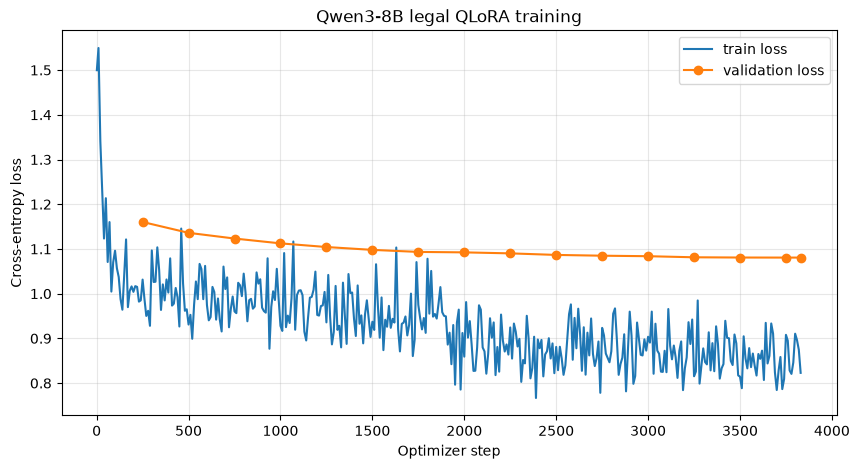

Saved: /data2/user_data/sg57092c/LLM_finetune/artifacts/qwen3_8b_qlora_training/training_curves.png
Run metadata saved: /data2/user_data/sg57092c/LLM_finetune/artifacts/qwen3_8b_qlora_training/training_summary.json


In [16]:
history = pd.DataFrame(trainer.state.log_history)
display(history.tail(10))

if not history.empty:
    fig, axis = plt.subplots(figsize=(10, 5))
    if "loss" in history:
        train_history = history.dropna(subset=["loss"])
        axis.plot(train_history["step"], train_history["loss"], label="train loss")
    if "eval_loss" in history:
        eval_history = history.dropna(subset=["eval_loss"])
        axis.plot(
            eval_history["step"],
            eval_history["eval_loss"],
            marker="o",
            label="validation loss",
        )
    axis.set_xlabel("Optimizer step")
    axis.set_ylabel("Cross-entropy loss")
    axis.set_title("Qwen3-8B legal QLoRA training")
    axis.legend()
    axis.grid(alpha=0.3)
    figure_path = ARTIFACT_DIR / "training_curves.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)

run_summary = {
    "model": MODEL_NAME,
    "adapter_directory": str(ADAPTER_DIR),
    "training_profile": TRAINING_PROFILE,
    "max_sequence_tokens": MAX_SEQUENCE_TOKENS,
    "smoke_test": SMOKE_TEST,
    "train_examples": len(tokenized_datasets["train"]),
    "validation_examples": len(tokenized_datasets["validation"]),
    "checkpoint_validation_examples": len(
        tokenized_datasets["checkpoint_validation"]
    ),
    "trainable_parameters": int(trainable_parameters),
    "trainable_percentage": float(trainable_percentage),
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "lora_target_modules": LORA_TARGET_MODULES,
    "effective_batch_size": effective_batch_size,
    "environment": environment,
    "checkpoint_evaluation_metrics": checkpoint_evaluation_metrics,
    "full_validation_metrics": evaluation_metrics,
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_metric": trainer.state.best_metric,
}
with open(ARTIFACT_DIR / "training_summary.json", "w", encoding="utf-8") as file:
    json.dump(run_summary, file, indent=2, default=str)

print("Run metadata saved:", ARTIFACT_DIR / "training_summary.json")

## 14. Post-training sanity generation

This is only a qualitative check on one validation chunk. Full ROUGE, BERTScore, factuality and document-level evaluation belong in notebook 05.

In [17]:
if RUN_TRAINING:
    model.eval()
    model.config.use_cache = True
    set_seed(RANDOM_SEED)

    example = raw_datasets["validation"][0]
    inputs = tokenizer(
        example["prompt"],
        add_special_tokens=False,
        return_tensors="pt",
    ).to(model.device)

    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            max_new_tokens=min(512, int(preprocessing_report["max_target_tokens"])),
            do_sample=True,
            temperature=0.7,
            top_p=0.8,
            top_k=20,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    prediction = tokenizer.decode(
        generated[0, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()

    print("CASE:", example["case_id"])
    print("\nPREDICTION:\n", prediction)
    print("\nREFERENCE CHUNK SUMMARY:\n", example["target_summary"])
else:
    print("Run training before the sanity-generation cell.")

CASE: 1002

PREDICTION:
 The appellants held personal inams which were covered by Bombay Acts II and VII of 1863. Under the latter Acts they paid only a small proportion of the land revenue and retained the rest for themselves. The Bombay Personal Inams Abolition Act, 1953, which was enacted under article 31A Of the Constitution, abolished the personal inams and made the inam holders liable to pay the full land revenue. No compensation was provided for the loss which the inamdar suffered by having to pay the full assessment. Held, that the Bombay Personal Inams Abolition Act, 1953, was not unconstitutional. The Act specifically dealt with inams and was protected under article 31A from any attack under articles 14, 19 and 31. Inams being estates, the right of the inamdar to retain part of the full assessment over and above the quit rent payable to the Government arose because he held the inam estate. The right could not be anything more than a right in an estate. Even if it were possibl

## 15. Handoff to notebook 05

The next notebook should load the saved PEFT adapter, generate summaries for validation and test chunk files, merge chunk outputs in chunk_index order, and compare them with document-level references.

Recommended evaluation:
- ROUGE-1, ROUGE-2 and ROUGE-L
- BERTScore
- entity and citation consistency
- unsupported-claim or hallucination rate
- latency, throughput and peak GPU memory
- base Qwen3-8B versus QLoRA-adapted Qwen3-8B